--- Лабораторная работа № 6: Модель эпидемии (SIR модель с пороговым значением) ---

In [2]:
using DifferentialEquations, Plots, LaTeXStrings

============================================================================
Модель эпидемии:
  S(t) - восприимчивые к болезни, но здоровые особи
  I(t) - инфицированные особи (распространители инфекции)
  R(t) - здоровые особи с иммунитетом

  I* - критическое число инфицированных, при превышении которого начинается заражение

Динамика:
  dS/dt = -α·S, если I > I*; иначе 0
  dI/dt =  α·S - β·I, если I > I*; иначе -β·I
  dR/dt = β·I
============================================================================

Выбор сценария: задайте параметры в зависимости от рассматриваемого случая

----------------------------------------------------------------------------
Сценарий А: I(0) ≤ I* (начальное число инфицированных не превышает порог)
----------------------------------------------------------------------------

In [6]:
println("\n" * "="^60)
println("СЦЕНАРИЙ А: I(0) ≤ I* (эпидемия не начинается сразу)")
println("="^60)


СЦЕНАРИЙ А: I(0) ≤ I* (эпидемия не начинается сразу)


Параметры для сценария А

In [8]:
α_A = 0.01      # коэффициент заболеваемости
β_A = 0.02      # коэффициент выздоровления
N_A = 2000      # общая численность популяции
I_star_A = 200  # критическое число инфицированных

200

Начальные условия для сценария А

In [10]:
I0_A = 100      # I(0) = 100 ≤ I* = 200
R0_A = 0        # начальное количество с иммунитетом
S0_A = N_A - I0_A - R0_A  # S0 = 1900

println("Параметры модели:")
println("α = $α_A  (коэффициент заболеваемости)")
println("β = $β_A  (коэффициент выздоровления)")
println("N = $N_A  (общая численность популяции)")
println("I* = $I_star_A  (критическое число инфицированных)")

println("\nНачальные условия:")
println("S(0) = $S0_A  (восприимчивые)")
println("I(0) = $I0_A  (инфицированные)")
println("R(0) = $R0_A  (с иммунитетом)")
println("I(0) = $I0_A ≤ I* = $I_star_A → эпидемия не начинается")

Параметры модели:
α = 0.01  (коэффициент заболеваемости)
β = 0.02  (коэффициент выздоровления)
N = 2000  (общая численность популяции)
I* = 200  (критическое число инфицированных)

Начальные условия:
S(0) = 1900  (восприимчивые)
I(0) = 100  (инфицированные)
R(0) = 0  (с иммунитетом)
I(0) = 100 ≤ I* = 200 → эпидемия не начинается


Функция для модели эпидемии

In [12]:
function epidemic!(du, u, p, t)
    α, β, I_star = p
    S, I, R = u

    if I > I_star
        du[1] = -α * S
        du[2] =  α * S - β * I
    else
        du[1] = 0.0
        du[2] = -β * I
    end
    du[3] = β * I
end

epidemic! (generic function with 1 method)

Решение для сценария А

In [14]:
tspan_A = (0.0, 200.0)
u0_A = [S0_A, I0_A, R0_A]
params_A = (α_A, β_A, I_star_A)

prob_A = ODEProblem(epidemic!, u0_A, tspan_A, params_A)
sol_A = solve(prob_A, saveat=0.5)

retcode: Success
Interpolation: 1st order linear
t: 401-element Vector{Float64}:
   0.0
   0.5
   1.0
   1.5
   2.0
   2.5
   3.0
   3.5
   4.0
   4.5
   5.0
   5.5
   6.0
   ⋮
 194.5
 195.0
 195.5
 196.0
 196.5
 197.0
 197.5
 198.0
 198.5
 199.0
 199.5
 200.0
u: 401-element Vector{Vector{Float64}}:
 [1900.0, 100.0, 0.0]
 [1900.0, 99.00498337383569, 0.995016626164313]
 [1900.0, 98.01986732547893, 1.9801326745210817]
 [1900.0, 97.04455335041041, 2.9554466495895917]
 [1900.0, 96.07894391462791, 3.9210560853720855]
 [1900.0, 95.12294245089574, 4.877057549104267]
 [1900.0, 94.17645335001504, 5.82354664998497]
 [1900.0, 93.23938179542336, 6.760618204576655]
 [1900.0, 92.31163414463504, 7.688365855364966]
 [1900.0, 91.39311775062684, 8.606882249373166]
 [1900.0, 90.48374083755796, 9.516259162442038]
 [1900.0, 89.58341250077011, 10.416587499229895]
 [1900.0, 88.69204270678745, 11.307957293212556]
 ⋮
 [1900.0, 2.044654442128871, 97.95534555787114]
 [1900.0, 2.0243140972927396, 97.9756859027072

Извлечение результатов для сценария А

In [16]:
t_A = sol_A.t
S_A = [u[1] for u in sol_A.u]
I_A = [u[2] for u in sol_A.u]
R_A = [u[3] for u in sol_A.u]

401-element Vector{Float64}:
  0.0
  0.995016626164313
  1.9801326745210817
  2.9554466495895917
  3.9210560853720855
  4.877057549104267
  5.82354664998497
  6.760618204576655
  7.688365855364966
  8.606882249373166
  9.516259162442038
 10.416587499229895
 11.307957293212556
  ⋮
 97.95534555787114
 97.97568590270727
 97.99582470690338
 98.01576402738601
 98.03550589787811
 98.05505232889897
 98.07440487684126
 98.0935648685515
 98.11253421500165
 98.13131481322972
 98.14990854145371
 98.16831725907166

----------------------------------------------------------------------------
Сценарий Б: I(0) > I* (начальное число инфицированных превышает порог)
----------------------------------------------------------------------------

In [18]:
println("\n" * "="^60)
println("СЦЕНАРИЙ Б: I(0) > I* (эпидемия начинается)")
println("="^60)


СЦЕНАРИЙ Б: I(0) > I* (эпидемия начинается)


Параметры для сценария Б

In [20]:
α_B = 0.01      # коэффициент заболеваемости
β_B = 0.02      # коэффициент выздоровления
N_B = 2000      # общая численность популяции
I_star_B = 100  # критическое число инфицированных

100

Начальные условия для сценария Б

In [22]:
I0_B = 300      # I(0) = 300 > I* = 100
R0_B = 0        # начальное количество с иммунитетом
S0_B = N_B - I0_B - R0_B  # S0 = 1700

println("Параметры модели:")
println("α = $α_B  (коэффициент заболеваемости)")
println("β = $β_B  (коэффициент выздоровления)")
println("N = $N_B  (общая численность популяции)")
println("I* = $I_star_B  (критическое число инфицированных)")

println("\nНачальные условия:")
println("S(0) = $S0_B  (восприимчивые)")
println("I(0) = $I0_B  (инфицированные)")
println("R(0) = $R0_B  (с иммунитетом)")
println("I(0) = $I0_B > I* = $I_star_B → эпидемия начинается")

Параметры модели:
α = 0.01  (коэффициент заболеваемости)
β = 0.02  (коэффициент выздоровления)
N = 2000  (общая численность популяции)
I* = 100  (критическое число инфицированных)

Начальные условия:
S(0) = 1700  (восприимчивые)
I(0) = 300  (инфицированные)
R(0) = 0  (с иммунитетом)
I(0) = 300 > I* = 100 → эпидемия начинается


Решение для сценария Б

In [24]:
tspan_B = (0.0, 200.0)
u0_B = [S0_B, I0_B, R0_B]
params_B = (α_B, β_B, I_star_B)

prob_B = ODEProblem(epidemic!, u0_B, tspan_B, params_B)
sol_B = solve(prob_B, saveat=0.5)

retcode: Success
Interpolation: 1st order linear
t: 401-element Vector{Float64}:
   0.0
   0.5
   1.0
   1.5
   2.0
   2.5
   3.0
   3.5
   4.0
   4.5
   5.0
   5.5
   6.0
   ⋮
 194.5
 195.0
 195.5
 196.0
 196.5
 197.0
 197.5
 198.0
 198.5
 199.0
 199.5
 200.0
u: 401-element Vector{Vector{Float64}}:
 [1700.0, 300.0, 0.0]
 [1691.5212146275549, 305.4514473788616, 3.027337993583701]
 [1683.0847173732554, 310.8065747527038, 6.10870787404078]
 [1674.69029731736, 316.06655056349604, 9.243152119143963]
 [1666.3377446080526, 321.2325301686271, 12.429725223320423]
 [1658.0268504367946, 326.3056564660274, 15.667493097178166]
 [1649.7574070280468, 331.28706015902696, 18.955532812926148]
 [1641.5292076392705, 336.17785975635525, 22.292932604374364]
 [1633.3420465609254, 340.9791615721409, 25.678791866933707]
 [1625.1957191159725, 345.69205973864337, 29.11222114538425]
 [1617.0900215816796, 350.317638203638, 32.59234021468241]
 [1609.0247513257991, 354.85696723281546, 36.11828144138559]
 [1600.9997

Извлечение результатов для сценария Б

In [26]:
t_B = sol_B.t
S_B = [u[1] for u in sol_B.u]
I_B = [u[2] for u in sol_B.u]
R_B = [u[3] for u in sol_B.u]

401-element Vector{Float64}:
    0.0
    3.027337993583701
    6.10870787404078
    9.243152119143963
   12.429725223320423
   15.667493097178166
   18.955532812926148
   22.292932604374364
   25.678791866933707
   29.11222114538425
   32.59234021468241
   36.11828144138559
   39.68918917944663
    ⋮
 1542.4697825391368
 1544.609768138412
 1546.7404714313457
 1548.8619230081242
 1550.974153435055
 1553.077193637128
 1555.1710930210947
 1557.2558936784762
 1559.3316276106946
 1561.398326791246
 1563.4560231657015
 1565.504748651706

----------------------------------------------------------------------------
Построение графиков для сценария А
----------------------------------------------------------------------------

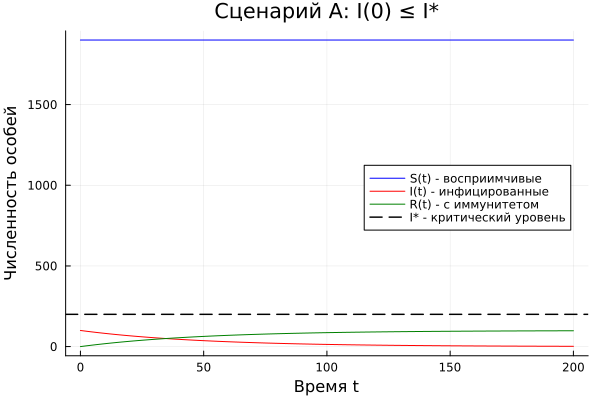

In [28]:
plot_A = plot(title="Сценарий А: I(0) ≤ I*",
              xlabel="Время t", ylabel="Численность особей",
              legend=:right, linewidth=2)

plot!(plot_A, t_A, S_A, label="S(t) - восприимчивые", color=:blue)
plot!(plot_A, t_A, I_A, label="I(t) - инфицированные", color=:red)
plot!(plot_A, t_A, R_A, label="R(t) - с иммунитетом", color=:green)

hline!(plot_A, [I_star_A], label="I* - критический уровень",
       color=:black, linestyle=:dash, linewidth=1.5)

----------------------------------------------------------------------------
Построение графиков для сценария Б
----------------------------------------------------------------------------

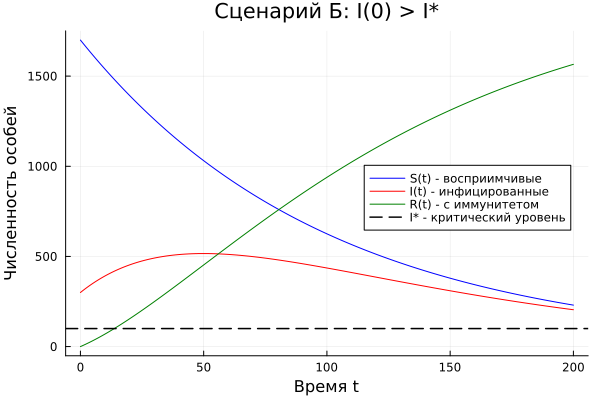

In [30]:
plot_B = plot(title="Сценарий Б: I(0) > I*",
              xlabel="Время t", ylabel="Численность особей",
              legend=:right, linewidth=2)

plot!(plot_B, t_B, S_B, label="S(t) - восприимчивые", color=:blue)
plot!(plot_B, t_B, I_B, label="I(t) - инфицированные", color=:red)
plot!(plot_B, t_B, R_B, label="R(t) - с иммунитетом", color=:green)

hline!(plot_B, [I_star_B], label="I* - критический уровень",
       color=:black, linestyle=:dash, linewidth=1.5)

Отображение графиков

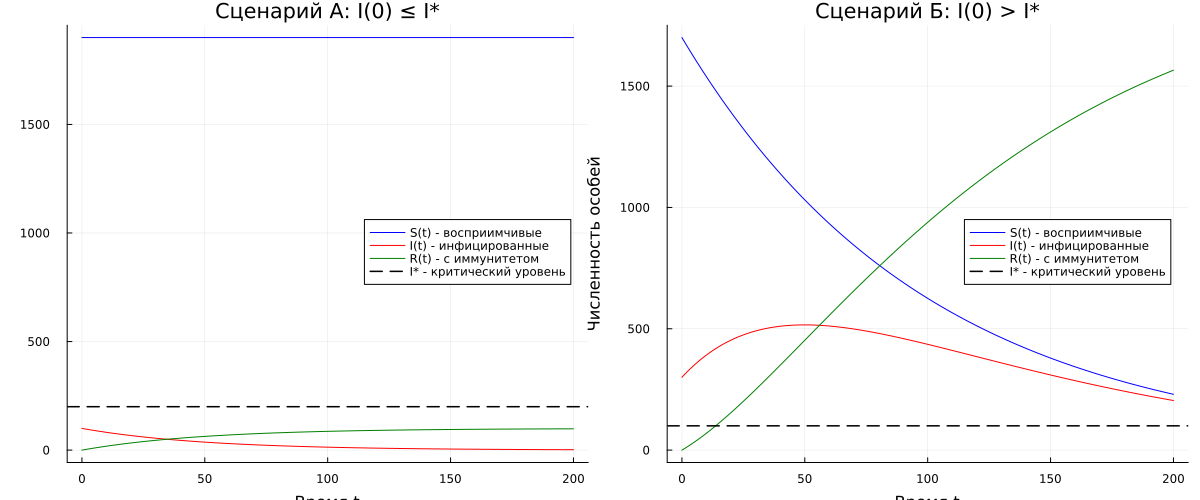

In [32]:
display(plot(plot_A, plot_B, layout=(1,2), size=(1200,500)))

----------------------------------------------------------------------------
Дополнительный анализ: исследование различных пороговых значений
----------------------------------------------------------------------------

In [34]:
println("\n" * "="^60)
println("Дополнительный анализ: влияние порогового значения I*")
println("="^60)


Дополнительный анализ: влияние порогового значения I*


Фиксируем начальные условия для сравнения

In [36]:
N_analysis = 2000
I0_analysis = 200
R0_analysis = 0
S0_analysis = N_analysis - I0_analysis - R0_analysis
α_analysis = 0.01
β_analysis = 0.02

0.02

Различные пороговые значения

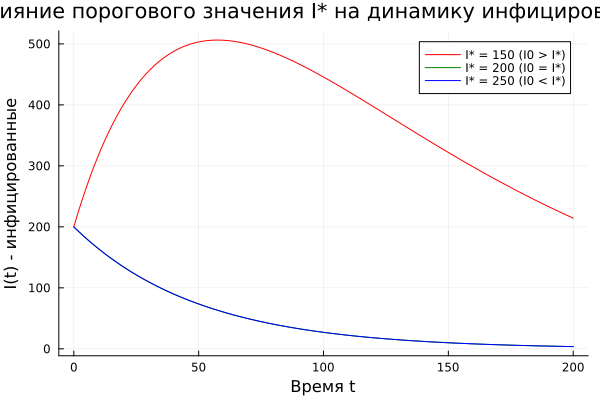

In [38]:
I_star_values = [150, 200, 250]
labels = ["I* = 150 (I0 > I*)", "I* = 200 (I0 = I*)", "I* = 250 (I0 < I*)"]
colors = [:red, :green, :blue]

plot_I_comparison = plot(title="Влияние порогового значения I* на динамику инфицированных",
                         xlabel="Время t", ylabel="I(t) - инфицированные",
                         legend=:topright, linewidth=2)

for (I_star, label, color) in zip(I_star_values, labels, colors)
    params_comp = (α_analysis, β_analysis, I_star)
    prob_comp = ODEProblem(epidemic!, [S0_analysis, I0_analysis, R0_analysis], tspan_A, params_comp)
    sol_comp = solve(prob_comp, saveat=0.5)
    I_comp = [u[2] for u in sol_comp.u]
    plot!(plot_I_comparison, t_A, I_comp, label=label, color=color)
end

display(plot_I_comparison)

----------------------------------------------------------------------------
Вывод анализа
----------------------------------------------------------------------------

In [40]:
println("\n" * "="^60)
println("Анализ результатов")
println("="^60)

println("\nСценарий А (I(0) ≤ I*):")
println("• Эпидемия не начинается, так как начальное число инфицированных не превышает порог")
println("• Инфицированные особи только выздоравливают: dI/dt = -β·I")
println("• Число инфицированных экспоненциально убывает до нуля")
println("• Восприимчивые особи не заражаются, так как dS/dt = 0")
println("• Популяция постепенно переходит в состояние с иммунитетом (R растет за счет выздоровления)")

println("\nСценарий Б (I(0) > I*):")
println("• Эпидемия начинается, так как порог превышен")
println("• Сначала число инфицированных растет за счет заражения восприимчивых")
println("• Достигается пик эпидемии, после чего число инфицированных снижается")
println("• Восприимчивые особи активно заражаются, S(t) убывает")
println("• Формируется коллективный иммунитет, R(t) растет")
println("• В итоге эпидемия затухает, I(t) → 0")

println("\nКлючевые выводы:")
println("1. Пороговое значение I* играет критическую роль в развитии эпидемии")
println("2. Если I(0) ≤ I*, эпидемия не распространяется (карантинные меры эффективны)")
println("3. Если I(0) > I*, начинается эпидемический процесс")
println("4. В модели учитывается, что больные изолированы до превышения порога I*")
println("5. После превышения порога начинается активное распространение инфекции")


Анализ результатов

Сценарий А (I(0) ≤ I*):
• Эпидемия не начинается, так как начальное число инфицированных не превышает порог
• Инфицированные особи только выздоравливают: dI/dt = -β·I
• Число инфицированных экспоненциально убывает до нуля
• Восприимчивые особи не заражаются, так как dS/dt = 0
• Популяция постепенно переходит в состояние с иммунитетом (R растет за счет выздоровления)

Сценарий Б (I(0) > I*):
• Эпидемия начинается, так как порог превышен
• Сначала число инфицированных растет за счет заражения восприимчивых
• Достигается пик эпидемии, после чего число инфицированных снижается
• Восприимчивые особи активно заражаются, S(t) убывает
• Формируется коллективный иммунитет, R(t) растет
• В итоге эпидемия затухает, I(t) → 0

Ключевые выводы:
1. Пороговое значение I* играет критическую роль в развитии эпидемии
2. Если I(0) ≤ I*, эпидемия не распространяется (карантинные меры эффективны)
3. Если I(0) > I*, начинается эпидемический процесс
4. В модели учитывается, что больные из

----------------------------------------------------------------------------
Сохранение всех графиков (опционально)
----------------------------------------------------------------------------

savefig(plot_A, "epidemic_case_A.png")
savefig(plot_B, "epidemic_case_B.png")
savefig(plot_I_comparison, "epidemic_comparison.png")